<a href="https://colab.research.google.com/github/mahigarg0403-blip/Customer-purchase-prediction_mahi_bhumika/blob/main/notebooks/%20step_8_full_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
#cell 1 : mount drive
from google.colab import drive

drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [6]:
#cell 2 : importing libraries
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import ttest_rel #ttest

In [21]:
#cell 3 : importing datasets and merging the datasets
import pandas as pd

path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'
lr = pd.read_csv(path + 'lr_results.csv')
rf = pd.read_csv(path + 'rf_results.csv')
xgb = pd.read_csv(path + 'xgb_results.csv')

model_comparison = pd.concat([lr, rf, xgb], ignore_index=True)
model_comparison.to_csv('model_comparison.csv', index=False)

x_train_lr = pd.read_csv(path + 'step 4/x_train_lr_final.csv')
x_test_lr = pd.read_csv(path + 'step 4/x_test_lr_final.csv')
y_train_lr = pd.read_csv(path + 'step 4/y_train_lr_final.csv').squeeze()
y_test_lr = pd.read_csv(path + 'step 4/y_test_lr_final.csv').squeeze()

x_train_tree = pd.read_csv(path + 'step 4/x_train_tree_final.csv')
x_test_tree = pd.read_csv(path + 'step 4/x_test_tree_final.csv')
y_train_tree = pd.read_csv(path + 'step 4/y_train_tree_final.csv').squeeze()
y_test_tree = pd.read_csv(path + 'step 4/y_test_tree_final.csv').squeeze()

In [22]:
#cell 4 : load models
lr_model = joblib.load(path + 'logistic_regression.pkl')
rf_model = joblib.load(path + 'random_forest.pkl')
xgb_model = joblib.load(path + 'xgboost.pkl')

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

In [25]:
#cell 5 : data iteration made easier
model_data = {
    'Logistic Regression': {
        'model': lr_model,
        'x_train': x_train_lr, 'x_test': x_test_lr,
        'y_train': y_train_lr, 'y_test': y_test_lr
    },
    'Random Forest': {
        'model': rf_model,
        'x_train': x_train_tree, 'x_test': x_test_tree,
        'y_train': y_train_tree, 'y_test': y_test_tree
    },
    'XGBoost': {
        'model': xgb_model,
        'x_train': x_train_tree, 'x_test': x_test_tree,
        'y_train': y_train_tree, 'y_test': y_test_tree
    }
}

In [28]:
#cell 6 : value consistency amongst the models
if ((y_test_lr.reset_index(drop=True) != y_test_tree.reset_index(drop=True)).all()) :
  print("y_test differs between LR and tree datasets — splits are not aligned!")
else :
  print("splits are aligned!")

splits are aligned!


In [30]:
#cell 7 : values of pred and prob
probs = {
    name: d['model'].predict_proba(d['x_test'])[:, 1]
    for name, d in model_data.items()
}
preds = {
    name: d['model'].predict(d['x_test'])
    for name, d in model_data.items()
}

y_test = y_test_lr #single metric after checkinng alignment

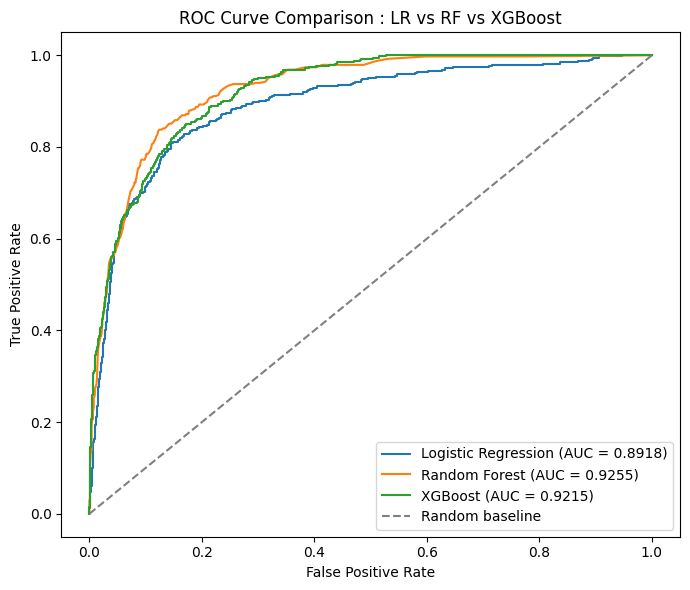

In [31]:
#cell 8 : overlaid ROC curves

plt.figure(figsize=(7, 6))
for name, y_prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison : LR vs RF vs XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()


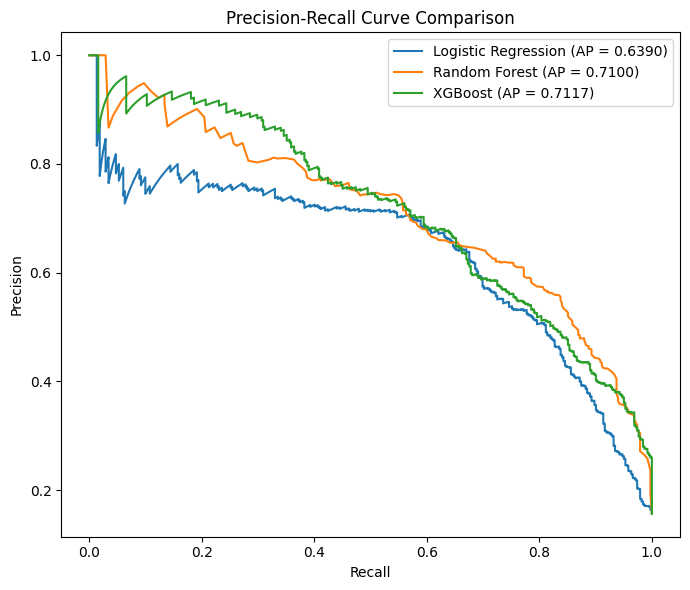

In [32]:
#cell 9 : overlaid precision-recall curves
plt.figure(figsize=(7, 6))
for name, y_prob in probs.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.4f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('pr_comparison.png', dpi=150)
plt.show()

In [33]:
#cell 10 : cross validation for all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, d in model_data.items():
    scores = cross_val_score(d['model'], d['x_train'], d['y_train'], cv=cv, scoring='f1', n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name}: mean F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: mean F1 = 0.8758 ± 0.0044
Random Forest: mean F1 = 0.9353 ± 0.0029
XGBoost: mean F1 = 0.9376 ± 0.0021


In [35]:
#cell 11 : Statistical significance : t-test on each pair of models
pairs = [
    ('Logistic Regression', 'Random Forest'),
    ('Random Forest', 'XGBoost'),
    ('Logistic Regression', 'XGBoost')
]

sig_results = []
for m1, m2 in pairs:
    t_stat, p_val = ttest_rel(cv_scores[m1], cv_scores[m2])
    sig_results.append({
        'comparison': f"{m1} vs {m2}",
        't_stat': t_stat,
        'p_value': p_val,
        'significant (p<0.05)': p_val < 0.05
    })

sig_df = pd.DataFrame(sig_results)
sig_df.to_csv('significance_test_results.csv', index=False)
print("Significance test results:")
sig_df

Significance test results:


,comparison,t_stat,p_value,significant (p<0.05)
0,Logistic Regression vs Random Forest,-48.740397,0.000001,True
1,Random Forest vs XGBoost,-1.676594,0.168929,False
2,Logistic Regression vs XGBoost,-39.666526,0.000002,True


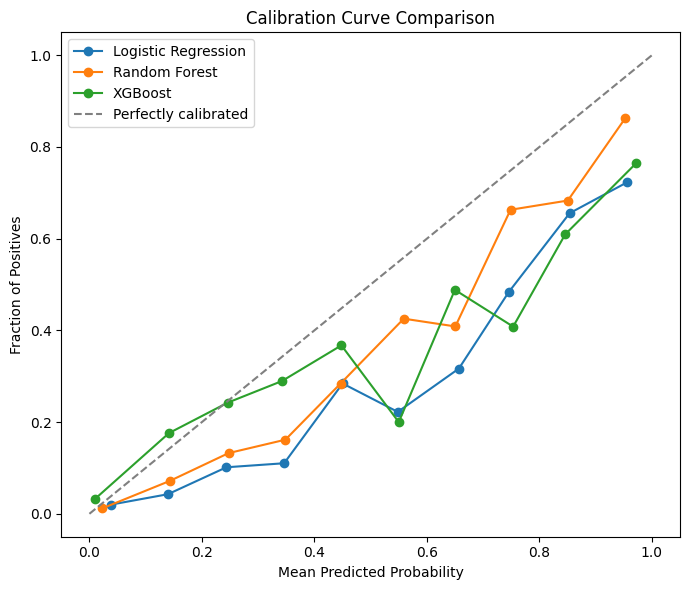

In [36]:
#cell 12 : calibration check : checks trustworthiness of probabilites
plt.figure(figsize=(7, 6))
for name, y_prob in probs.items():
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('calibration_comparison.png', dpi=150)
plt.show()

In [37]:
#cell 13 : error analysis
error_df = pd.DataFrame({
    'y_true': y_test.reset_index(drop=True),
    'lr_pred': preds['Logistic Regression'],
    'rf_pred': preds['Random Forest'],
    'xgb_pred': preds['XGBoost']
})

# rows where all models got it wrong
all_wrong = error_df[
    (error_df['lr_pred'] != error_df['y_true']) &
    (error_df['rf_pred'] != error_df['y_true']) &
    (error_df['xgb_pred'] != error_df['y_true'])
]

# rows where models dont agree with each other
disagreements = error_df[
    ~((error_df['lr_pred'] == error_df['rf_pred']) &
      (error_df['rf_pred'] == error_df['xgb_pred']))
]

print(f"\nRows all 3 models got wrong: {len(all_wrong)}")
print(f"Rows where models disagreed: {len(disagreements)}")

error_df.to_csv('error_analysis.csv', index=False)


Rows all 3 models got wrong: 163
Rows where models disagreed: 299


In [39]:
#cell 14 : saving full comparision table
final_table = model_comparison.copy()
final_table['cv_f1_mean'] = final_table['Model'].map(lambda m: cv_scores[m].mean())
final_table['cv_f1_std'] = final_table['Model'].map(lambda m: cv_scores[m].std())
final_table = final_table.sort_values('cv_f1_mean', ascending=False)

final_table.to_csv('final_model_comparison.csv', index=False)
print("\nFinal ranked comparison table:\n", final_table)


Final ranked comparison table:
                  Model  Accuracy      F1  Precision  Recall     AUC  \
2              XGBoost    0.8615  0.6373     0.5400  0.7775  0.9230   
1        Random Forest    0.8865  0.6768     0.6105  0.7592  0.9255   
0  Logistic Regression    0.8636  0.6279     0.5478  0.7356  0.8918   

   Best_n_estimators  Best_max_depth  cv_f1_mean  cv_f1_std  
2                NaN             NaN    0.937628   0.002115  
1              200.0             NaN    0.935341   0.002909  
0                NaN             NaN    0.875772   0.004388  


In [43]:
#cell 15 : saving all files and plots
import shutil
path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'


for plot in ['model_comparison.csv','roc_comparison.png', 'pr_comparison.png', 'significance_test_results.csv','calibration_comparison.png','final_model_comparison.csv']:
    shutil.copy(plot, path + plot)

print("Saved!")

Saved!
